In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import pandas as pd
import scoringrules as sr
sns.set_theme('notebook','white')
from torch.distributions import Categorical, Normal, MixtureSameFamily
import torch
from PIL import Image

# Build example TS, gaussian mixture stochastic noise

In [2]:

# 1-D case (again)
mix = Categorical(torch.tensor([7/8, 1/8]))
comp= Normal(loc = torch.tensor([0.0, 0.0]),
             scale=torch.tensor([8/14, 4]).sqrt())

gmm = MixtureSameFamily(mix, comp)              # full distribution object


# density, log-prob, etc.
logp = gmm.log_prob(torch.linspace(-10, 10, 100))

In [3]:
n_samples = 2000
idx = gmm.mixture_distribution.sample((n_samples,))        # tensor of 0s & 1s, shape (n_samples,)

# draw from the *two* normals, shape -> (n_samples, n_components)
raw = gmm.component_distribution.sample((n_samples,))

# keep only the column that was actually chosen
y = raw[torch.arange(n_samples), idx]   

conf = Normal(0.0, torch.sqrt(torch.tensor(8/14)))
pess = Normal(0.0, torch.sqrt(torch.tensor(4)))
trend = torch.tensor(np.arange(n_samples)/300 + 2*np.sin(np.arange(n_samples)/100))

y = trend+y
res =y -trend

## Make animation with signal

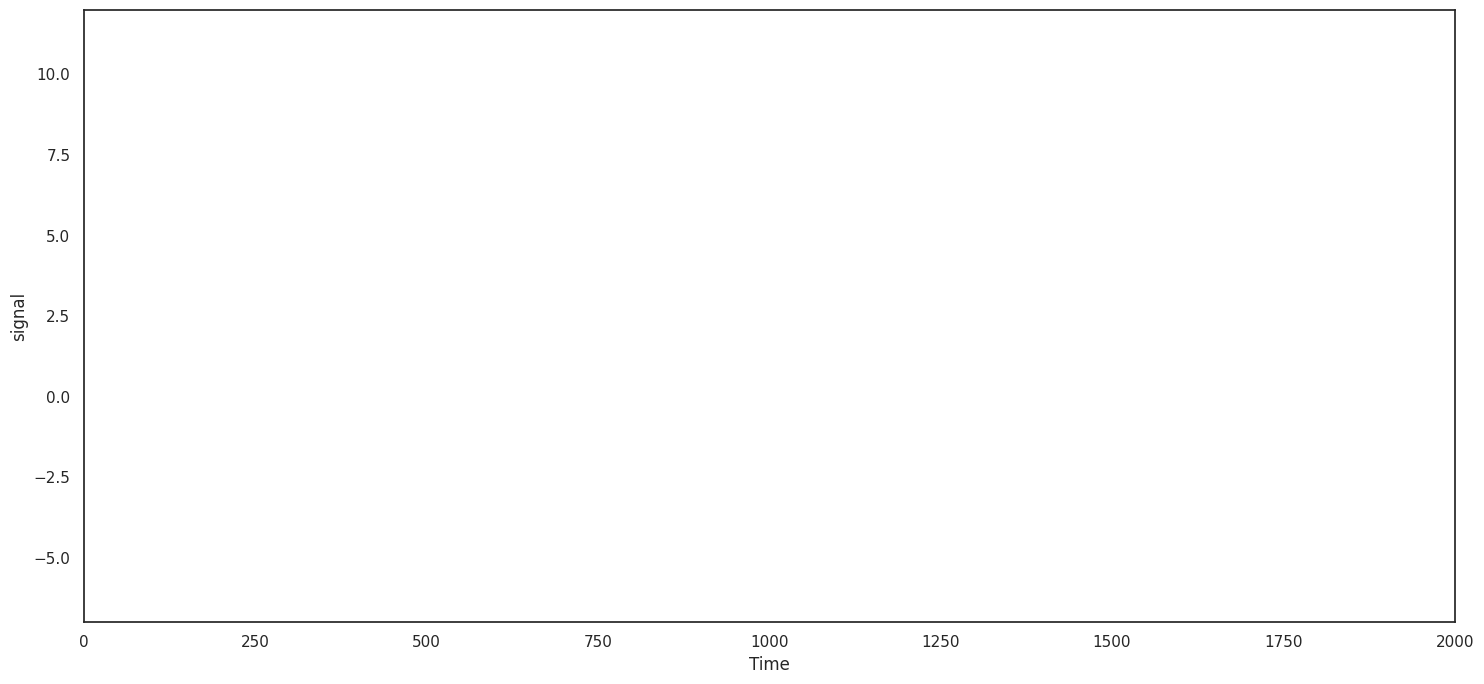

In [65]:
plt.figure(figsize = (15,7))
plt.xlim(0,2000)
plt.xlabel('Time')
plt.ylabel('signal')
plt.ylim(-7,12)
plt.tight_layout()

for i in range(200):
    index = np.linspace(0,2000, 200).astype(int)
    plt.plot(y[:index[i]], color = 'dimgrey', linestyle = "--", lw = 1.2)
    plt.savefig(f'./frames/{i}', transparent = True)
    plt.clf()
    plt.xlim(0,2000)
    plt.ylim(-7,12)
    plt.xlabel('Time')
    plt.ylabel('signal')
    plt.tight_layout()

In [66]:
# make_gif.py
# pip install Pillow

from pathlib import Path
from PIL import Image

# ------------------------------------------------------------------
# CONFIG – change these two if you like
FRAMES_DIR = Path("frames")      # where 0.png, 1.png … live
FPS        = 24                # frames per second (gif speed)
OUT_GIF    = "animation.gif"     # output file name
# ------------------------------------------------------------------

# Milliseconds each frame should stay on-screen
duration = round(1000 / FPS)

# Get all *.png, keep numeric order (0.png, 1.png … 199.png)
paths = sorted(FRAMES_DIR.glob("*.png"), key=lambda p: int(p.stem))
if len(paths) == 0:
    raise SystemExit(f"No PNGs found in {FRAMES_DIR}")

# Open first frame (sets size, palette reference)
first = Image.open(paths[0]).convert("RGBA")

# Load the rest, resize if somebody slipped in a different size
others = []
w, h = first.size
for p in paths[1:]:
    img = Image.open(p).convert("RGBA")
    if img.size != (w, h):
        img = img.resize((w, h), Image.LANCZOS)
    others.append(img)



# Write the gif
first.save(
    OUT_GIF,
    save_all=True,
    append_images=others,
    duration=duration,  # ms per frame
    loop=0,             # 0 = loop forever
    disposal=2,         # restore to background between frames (no trails)
    optimize=True,
)

print(f"Saved {OUT_GIF} ({len(paths)} frames, {FPS} fps)")

Saved animation.gif (200 frames, 24 fps)


## Plot different probabilistic models

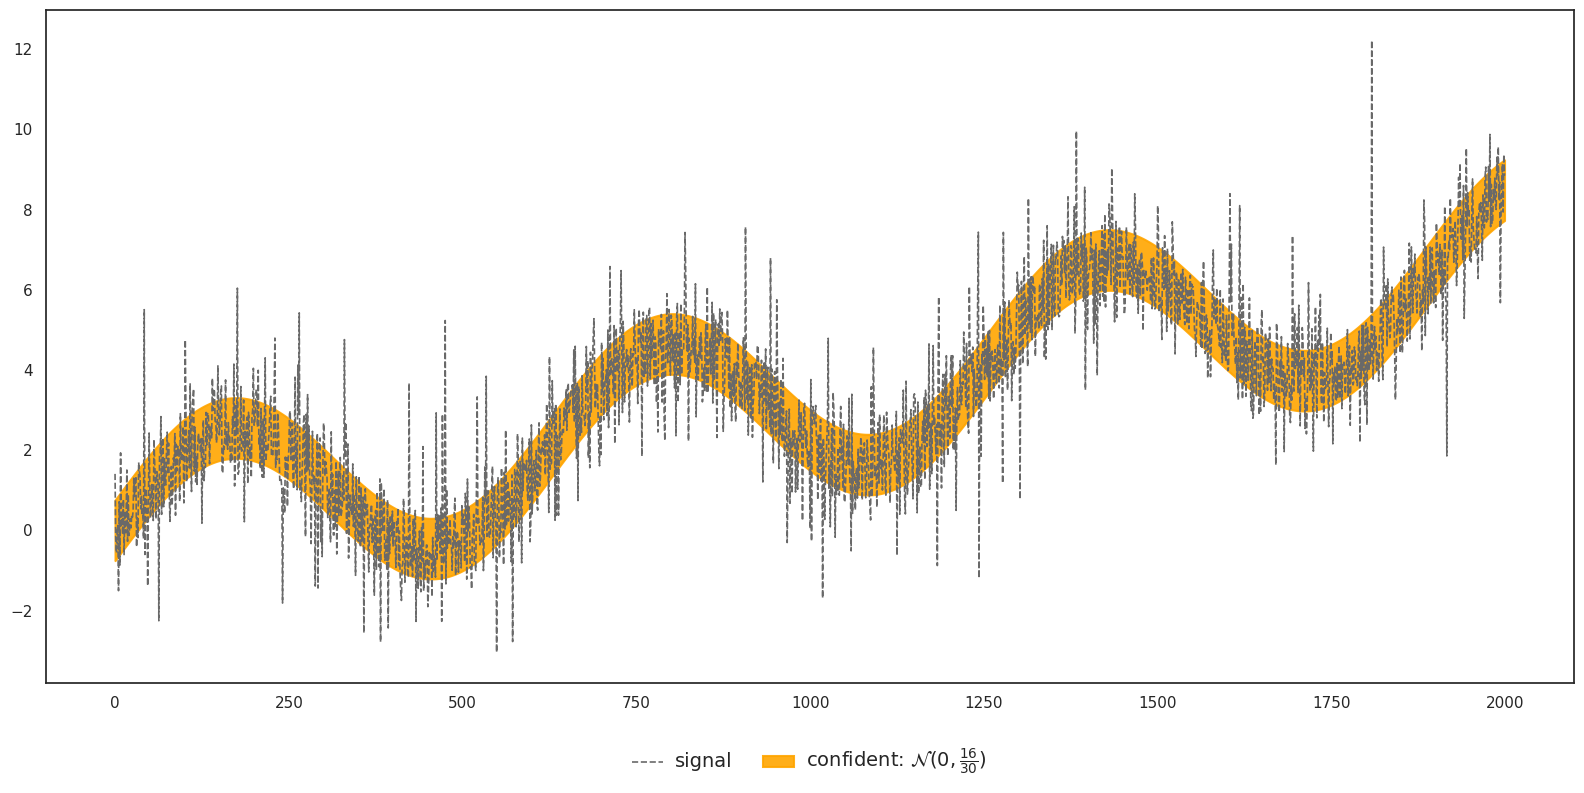

In [52]:
plt.figure(figsize = (16,8))
plt.plot(y, alpha = 1, color = 'dimgrey', linestyle = '--', zorder = 10, lw = 1.2, label = 'signal')
plt.fill_between(x=range(2000), y1=trend -conf.stddev.repeat(2000), y2= trend+conf.stddev.repeat(2000), color = 'orange', zorder = 2, alpha = .9, lw = 1.5, label = 'confident')

leg = plt.legend(['signal',r'confident: $\mathcal{N}(0,\frac{16}{30})$'], loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol = 5, frameon = False)
for i,text in enumerate(leg.get_texts()) :
    text.set_size(14)
plt.tight_layout()
plt.savefig('confident_model', dpi = 300, transparent = True)

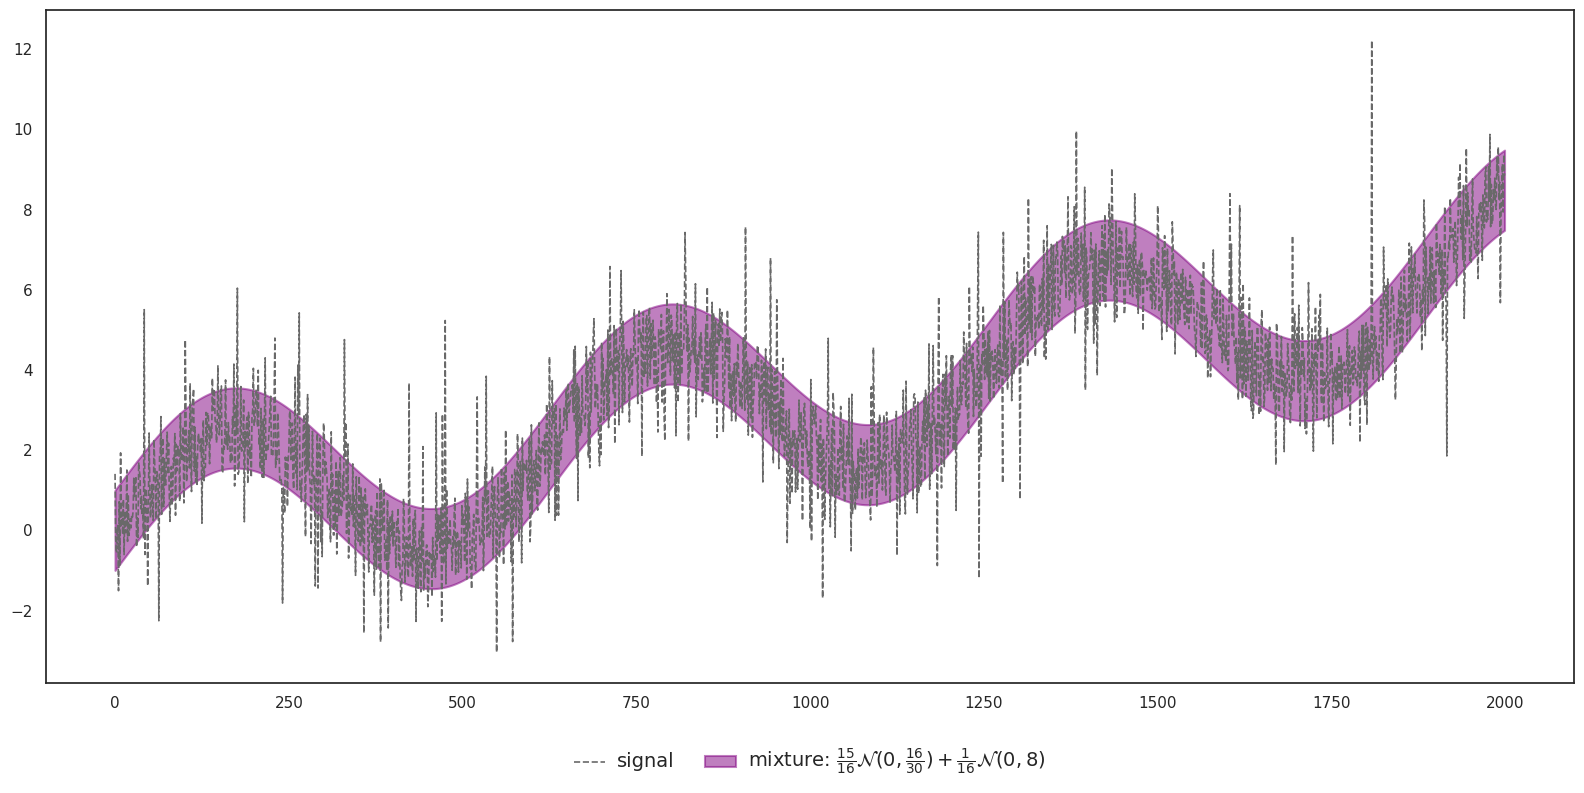

In [53]:
plt.figure(figsize = (16,8))
plt.plot(y, alpha = 1, color = 'dimgrey', linestyle = '--', zorder = 10, lw = 1.2, label = 'signal')
plt.fill_between(x=range(2000), y1= trend-gmm.stddev.repeat(2000), y2= trend + gmm.stddev.repeat(2000), color = 'purple', zorder = 1, alpha = 0.5, lw = 1.5, label = 'mixture')
leg = plt.legend(['signal',r'mixture: $\frac{15}{16}\mathcal{N}(0,\frac{16}{30}) + \frac{1}{16}\mathcal{N}(0,8)$'], loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol = 5, frameon = False)
for i,text in enumerate(leg.get_texts()) :
    text.set_size(14)
plt.tight_layout()
plt.savefig('mixture_model', dpi = 300, transparent = True)

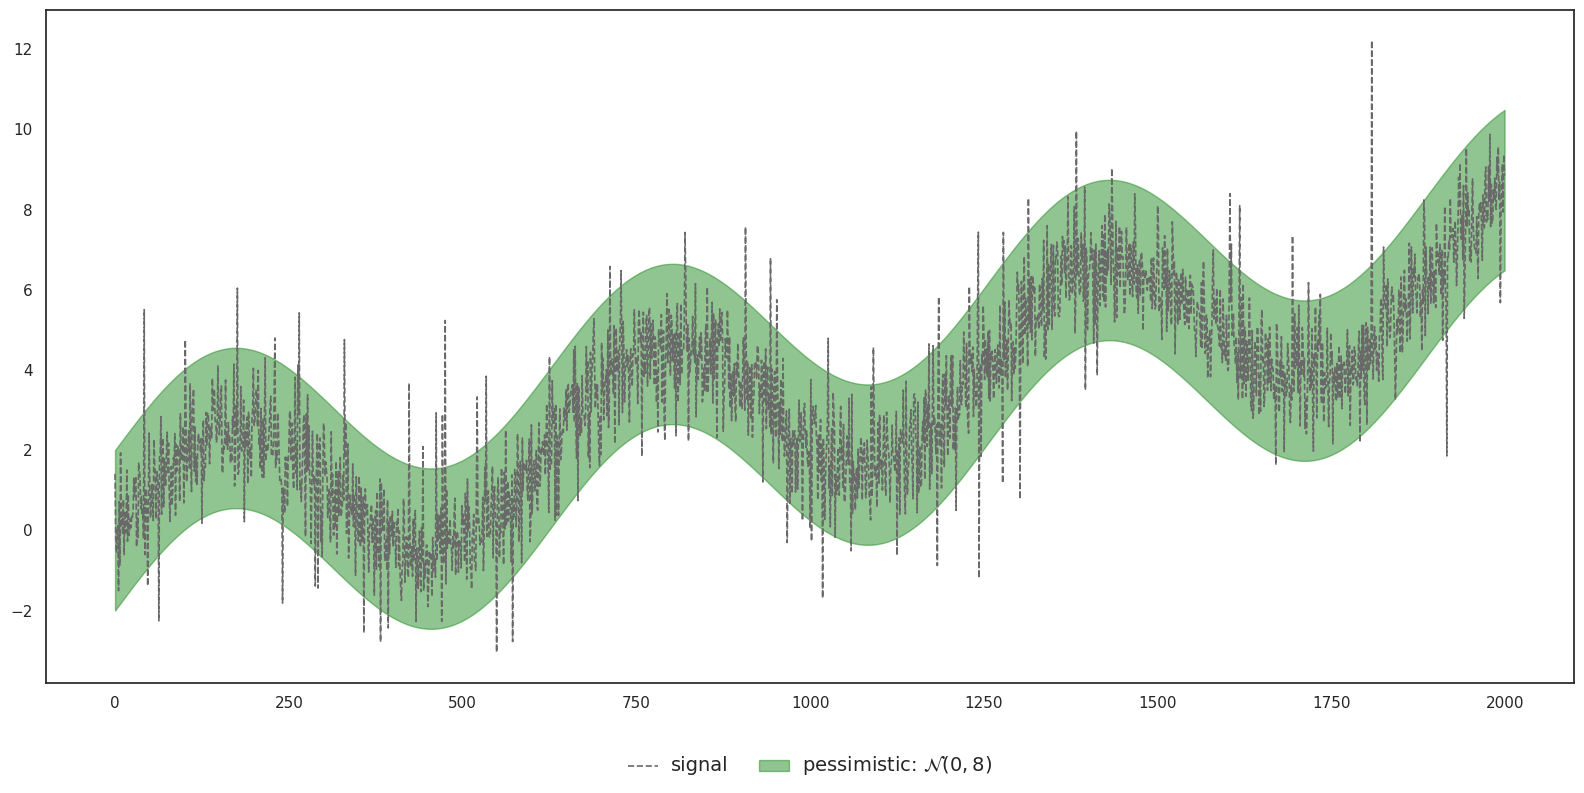

In [54]:
plt.figure(figsize = (16,8))
plt.plot(y, alpha = 1, color = 'dimgrey', linestyle = '--', zorder = 10, lw = 1.2, label = 'signal')
plt.fill_between(x=range(2000), y1= trend-pess.stddev.repeat(2000), y2= trend + pess.stddev.repeat(2000), color = 'forestgreen', zorder = 0, alpha = 0.5, label = 'pessimistic')

leg = plt.legend(['signal', r'pessimistic: $\mathcal{N}(0,8)$'], loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol = 5, frameon = False)
for i,text in enumerate(leg.get_texts()) :
    text.set_size(14)
plt.tight_layout()
plt.savefig('pessimistic_model', dpi = 300, transparent = True)

In [55]:
std = torch.zeros(n_samples)
for i,a in enumerate(idx) :
    if a == 0:
        std[i] = float(conf.stddev)
    elif a == 1:
        std[i] = float(pess.stddev)

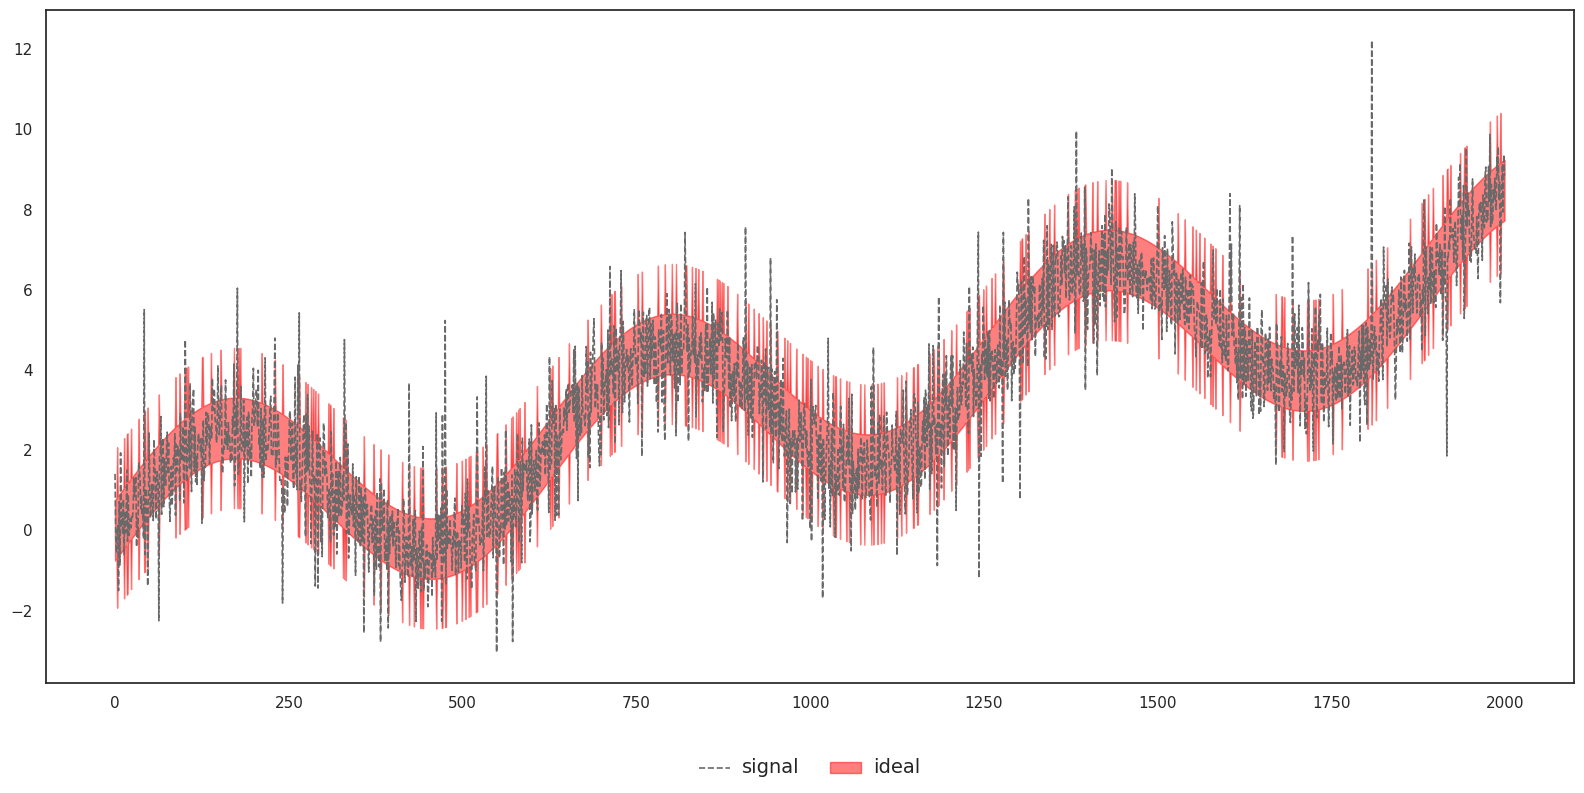

In [56]:
plt.figure(figsize = (16,8))
plt.plot(y, alpha = 1, color = 'dimgrey', linestyle = '--', zorder = 10, lw = 1.2, label = 'signal')
plt.fill_between(x=range(2000), y1= trend-std, y2= trend + std, color = 'red', zorder = 0, alpha = 0.5, label = 'ideal')
leg = plt.legend(['signal', r'ideal'], loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol = 5, frameon = False)
for i,text in enumerate(leg.get_texts()) :
    text.set_size(14)
plt.tight_layout()
plt.savefig('ideal_model', dpi = 300, transparent = True)

## Scoring forecasts

In [4]:
id_score = []
pess_score = - pess.log_prob(res)
conf_score = - conf.log_prob(res)
for i,a in enumerate(idx) :
    if a == 0:
        id_score.append(conf_score[i])
    elif a == 1:
        id_score.append(pess_score[i])

log_score = {}
log_score['gmm'] = torch.mean(-gmm.log_prob(res)).item()
log_score['conf'] = torch.mean(-conf.log_prob(res)).item()
log_score['pess'] = torch.mean(-pess.log_prob(res)).item()
log_score['ideal'] = np.mean(id_score)


In [6]:
def crps_gaussian(mu, sigma, y):
    mu = np.asarray(mu)
    sigma = np.asarray(sigma)
    y = np.asarray(y)

    z = (y - mu) / sigma
    phi = norm.pdf(z)
    Phi = norm.cdf(z)

    # Closed-form expression for CRPS
    crps = sigma * (z * (2 * Phi - 1) + 2 * phi - 1/np.sqrt(np.pi))
    return crps

results = {}
results['gmm'] = np.mean(sr.crps_mixnorm(res,[0,0], [np.sqrt(4),np.sqrt(8/14)], w = [1/8,7/8]))
results['conf'] = np.mean(crps_gaussian(mu = 0, sigma= np.sqrt(8/14), y = res))
results['pess'] =np.mean(crps_gaussian(mu = 0, sigma= np.sqrt(4), y = res))
rawscore = np.array((crps_gaussian(mu = 0, sigma= np.sqrt(8/14), y = res),crps_gaussian(mu = 0, sigma= np.sqrt(4), y = res)),)
crps_id = rawscore[idx,torch.arange(n_samples)]
results['ideal'] = np.mean(crps_id)

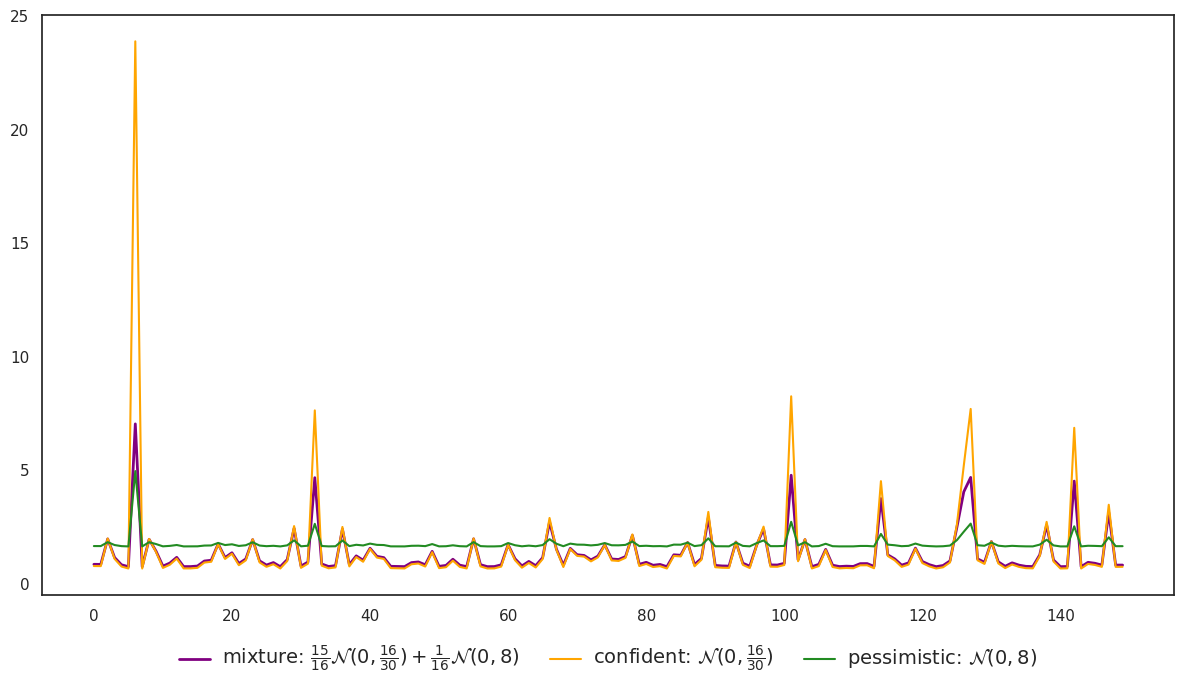

In [7]:
plt.figure(figsize=(12,7))
# plt.plot(id_score[:150], color = "red", lw =0.8, zorder = 5)
plt.plot(-gmm.log_prob(res)[:150], color = "purple", lw =2)
plt.plot(-conf.log_prob(res)[:150], color = "orange", lw =1.5)
plt.plot(-pess.log_prob(res)[:150], color = 'forestgreen')
leg = plt.legend([r'mixture: $\frac{15}{16}\mathcal{N}(0,\frac{16}{30}) + \frac{1}{16}\mathcal{N}(0,8)$', r'confident: $\mathcal{N}(0,\frac{16}{30})$', r'pessimistic: $\mathcal{N}(0,8)$'], loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol = 5, frameon = False)
for i,text in enumerate(leg.get_texts()) :
    text.set_size(14)
plt.tight_layout()
plt.savefig('error_log', dpi = 300, transparent = True)

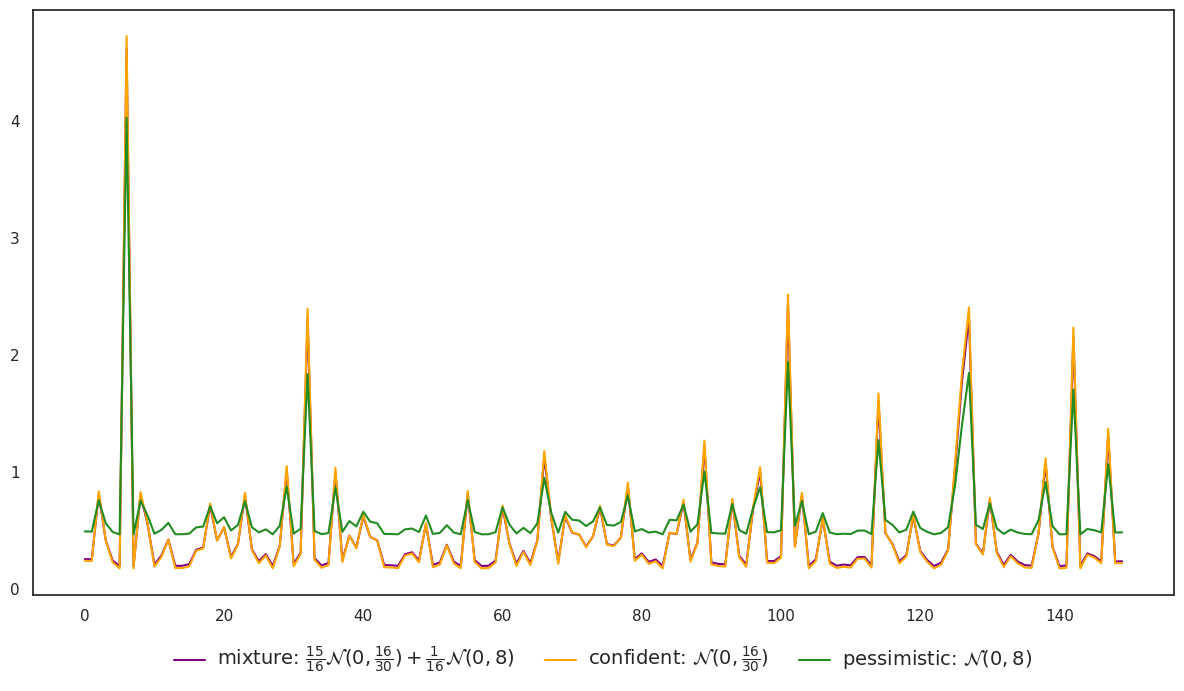

In [8]:
plt.figure(figsize=(12,7))
plt.plot(sr.crps_mixnorm(res,[0,0], [np.sqrt(4),np.sqrt(8/14)], w = [1/8,7/8])[:150], color = 'purple')
plt.plot(crps_gaussian(mu = 0, sigma= np.sqrt(8/14), y = res)[:150], color ='orange')
plt.plot(crps_gaussian(mu = 0, sigma= np.sqrt(4), y = res)[:150], color = 'forestgreen')
leg = plt.legend([r'mixture: $\frac{15}{16}\mathcal{N}(0,\frac{16}{30}) + \frac{1}{16}\mathcal{N}(0,8)$', r'confident: $\mathcal{N}(0,\frac{16}{30})$', r'pessimistic: $\mathcal{N}(0,8)$'], loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol = 5, frameon = False)
for i,text in enumerate(leg.get_texts()) :
    text.set_size(14)
plt.tight_layout()
plt.savefig('crps_error', dpi = 300, transparent = True)

## Avg error / ranking

In [9]:
df = pd.DataFrame((results,log_score), index = range(2))
out = df.copy()

ref = out.iloc[:, -1]                         # Series, shape (n_rows,)

# Vectorised broadcast along rows (axis=0)
out.iloc[:, :-1] = (out.iloc[:, :-1]
                    .sub(ref, axis=0)         # numerator
                    .div(ref, axis=0)         # divide by reference
                    .mul(100))                # convert to %
out['ideal'] = 0
out= out.rename(columns={'gmm' : 'mixture', 'conf':'confident', 'pess':'pessimistic'})
out = out[['ideal','mixture','confident', 'pessimistic']]

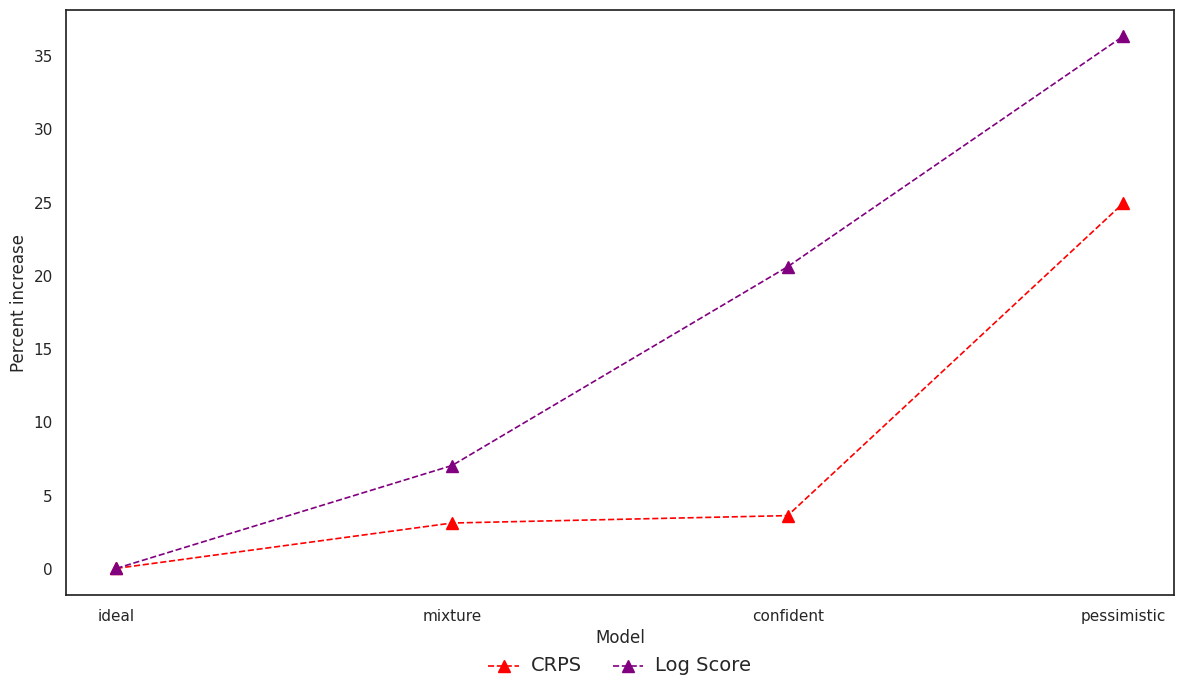

In [10]:
plt.figure(figsize=(12,7))
plt.plot(out.iloc[0], linestyle = '--', marker = '^', color = 'red', lw = 1.2, ms = 8)
plt.plot(out.iloc[1], linestyle = '--', marker = '^', color = 'purple', lw = 1.2, ms = 8)
plt.ylabel('Percent increase')
plt.xlabel('Model')
leg = plt.legend(['CRPS','Log Score'], loc='lower center', bbox_to_anchor=(0.5, -0.16), ncol = 5, frameon = False)
for i,text in enumerate(leg.get_texts()) :
    text.set_size(14)
plt.tight_layout()
plt.savefig('average_error', dpi = 300, transparent= True)

## 2D histogram : scaled dependence for gaussian scale misspecification

In [11]:
from matplotlib.colors import PowerNorm, SymLogNorm


SQRT_PI = np.sqrt(np.pi)

def E_CRPS1(delta):
    Res = []
    for i in range(len(delta)):
        res = []
        for d in delta[i] :
            s2 = 2 * d
            z = np.random.normal(0,4, size = 5000)
            exp_crps = np.mean(crps_gaussian(mu=0,sigma=np.square(s2), y = z))
            res.append(exp_crps)
        Res.append(res)
    return np.array(Res)
def E_CRPS2(delta):
    """
    E[CRPS]/σ   for a mean-zero N(0,σ²) when the predictive model
    uses σ̂ = δ·σ         (Friederichs & Thorarinsdottir, 2012, eq. 7)
    """
    Res = []
    for i in range(len(delta)):
        res = []
        for d in delta[i] :
            s2 = 1 * d
            z = np.random.normal(0,np.square(1), size = 5000)
            exp_crps = np.mean(crps_gaussian(mu=0,sigma=np.sqrt(s2), y = z))
            res.append(exp_crps)
        Res.append(res)
    return np.array(Res)

def E_logS(delta):
    """
    Expected (negative) log–score   –E[log p̂(Y)]
    with σ̂ = δ·σ  and μ̂ = 0   (straightforward integration)
    """
    return  np.log(delta) + 1 / (2*delta**2) - 1/2


def get_hist(n_points):
    # -----------------------------------------------------------------
    # build the grid  (δ̂₁ , δ̂₂)
    # -----------------------------------------------------------------
    delta  = np.linspace(0.1, 3, n_points)
    D1, D2 = np.meshgrid(delta, delta)              # shape (n,n)

    # -----------------------------------------------------------------
    # scores on the grid (average of the two margins, centred at zero)
    # -----------------------------------------------------------------
    CRPS = 0.5 * (E_CRPS2(D1)  + E_CRPS1(D2)) 
    LOGS = 0.5 * (E_logS(D1) + E_logS(D2))   
    LOGS = np.log(np.maximum(LOGS, 1e-12))  # paper shows log(LS)
    return delta, CRPS, LOGS
# ---------------------------------------------------------------------
# plot maker
# ---------------------------------------------------------------------
def variance_error_plots(n_points: int = 200):
    """
    Draw the 2-D contour/heat-maps for variance miss-specification:

        x–axis :  δ̂₁ = σ̂₁ / σ₁   (0.1 … 3.5)
        y–axis :  δ̂₂ = σ̂₂ / σ₂   (0.1 … 3.5)

    The colour encodes the *average* score of the two margins, centred so
    that the optimum at (1,1) is shown as 0.
    """
   
    delta, CRPS, LOGS = get_hist(n_points)
    vmax = np.percentile(np.r_[CRPS.ravel(), LOGS.ravel()], 99.5)
    norm_common = PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax)
    # -----------------------------------------------------------------
    # figure
    # -----------------------------------------------------------------
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    cmap = "coolwarm_r"
    norm_logs = SymLogNorm(linthresh=1e-2, vmin=LOGS.min(), vmax=LOGS.max())

    # --- CRPS ---------------------------------------------------------
    h1 = axs[0].contourf(delta, delta, CRPS, 40, cmap=cmap)
    axs[0].contour(delta, delta, CRPS, 30, colors='k', linewidths=.6)
    axs[0].set_title("CRPS (variance error)", fontsize=13)
    axs[0].set_xlabel(r"$\delta = \hat{\sigma}_1 / \sigma_1$")
    axs[0].set_ylabel(r"$\delta = \hat{\sigma}_2 / \sigma_2$")
    plt.colorbar(h1, ax=axs[0], shrink=.8)

    # --- log(LS) ------------------------------------------------------
    h2 = axs[1].contourf(delta, delta, LOGS, 40, cmap=cmap)
    axs[1].contour(delta, delta, LOGS, 20, colors='k', linewidths=.6)
    axs[1].set_title(r"$\log(\mathrm{LS})$ (variance error)", fontsize=13)
    axs[1].set_xlabel(r"$\hat{\sigma}_1 / \sigma_1$")
    plt.colorbar(h2, ax=axs[1], shrink=.8)

    fig.suptitle(r"$\sigma_1 = 1 ,\; \sigma_2 = 2$", fontsize=14)
    return fig


    

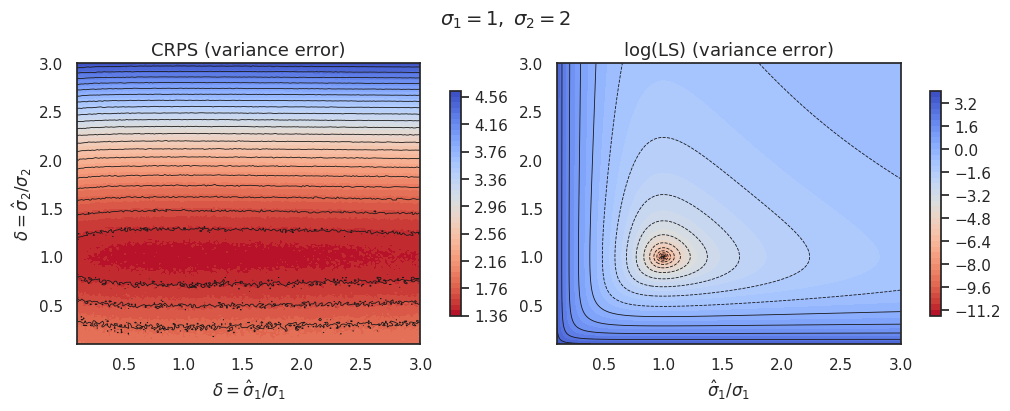

In [12]:
variance_error_plots()
plt.savefig('./hist2dplots', dpi = 300, transparent = True)